# Risco e Precificação de Veículos com Dados FIPE
### Pipeline analítico ponta a ponta: API pública → EDA → Score de Risco → Machine Learning

**Pergunta de negócio:** *quais perfis de veículo merecem precificação diferenciada em uma carteira de proteção veicular?*

Uma associação de proteção veicular precisa equilibrar competitividade e sustentabilidade da carteira. Cobrar igual de
veículos com riscos diferentes gera **seleção adversa**: os bons riscos saem, os maus riscos ficam. Este notebook constrói,
a partir de dados públicos, um instrumento quantitativo para segmentar a carteira por risco.

**Fontes de dados (documentação completa):**

| Fonte | O que fornece | Acesso | Como entra no pipeline |
|---|---|---|---|
| **API FIPE** (parallelum.com.br) | Valor de mercado por marca/modelo/ano, atualização mensal | [`parallelum.com.br/fipe/api/v1`](https://parallelum.com.br/fipe/api/v1) — gratuita, 500 req/dia (1.000 com token) | Seção 2: ingestão direta via REST (fallback sintético calibrado se offline) |
| **SUSEP — IVR** (Índice de Veículos Roubados) | Frequência relativa de roubo por veículo/região/ano — índice oficial do regulador de seguros | [Formulário oficial](https://www2.susep.gov.br/menuestatistica/rankroubo/menu1.asp) — export manual (não há API) | Seção 2.2: lido de `data/ivr_susep*.csv` e acoplado por fuzzy match. O repositório inclui **amostra ilustrativa** com a estrutura real; substitua pelo export oficial |
| **BCB/SGS** *(extensão futura)* | Séries macro (Selic, IPCA, inadimplência) | [`api.bcb.gov.br/dados/serie/bcdata.sgs.{cod}/dados?formato=json`](https://dadosabertos.bcb.gov.br) | Roadmap: sensibilidade da carteira ao ciclo de crédito |

**Roteiro:** 1. Ingestão → 2. EDA → 3. Curvas de depreciação → 4. Score de risco → 5. ML (segmentação + regressão) → 6. Conclusões


## 1 · Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'legend.fontsize': 10,
})

# Paleta amigável a daltônicos (azul/laranja como par primário)
PAL = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
sns.set_palette(PAL)

SEED = 42
rng = np.random.default_rng(SEED)

def fmt_brl(v, _=None):
    if abs(v) >= 1e6: return f'R$ {v/1e6:.1f}M'
    if abs(v) >= 1e3: return f'R$ {v/1e3:.0f}k'
    return f'R$ {v:,.0f}'


## 2 · Ingestão

Duas fontes, dois caminhos:

**FIPE (valores):** a célula tenta a **API real**; sem internet, cai num **gerador sintético calibrado** (valores 2026,
depreciação composta por segmento, ruído log-normal). No modo sintético, o índice de furto já vem embutido no catálogo
para fins de demonstração.

**SUSEP — IVR (furto/roubo):** não há API; o índice é exportado manualmente do
[formulário oficial](https://www2.susep.gov.br/menuestatistica/rankroubo/menu1.asp) para `data/ivr_susep.csv`
(colunas: `descricao; ano_modelo; indice`). A seção 2.2 acopla esse CSV à base FIPE por casamento aproximado de nomes.
Se o arquivo não existir, o fator entra **neutro (50) com aviso explícito** — a análise roda, mas o peso de 40% do
furto fica inerte até você plugar o dado real.

In [2]:
import json, time
from pathlib import Path

def coletar_fipe_api(marcas={'21': 'Fiat', '59': 'VW', '25': 'Honda'}, limite_modelos=4):
    """Coleta real: marcas -> modelos -> anos -> preço. Respeita rate limit (500 req/dia)."""
    import requests
    BASE = 'https://parallelum.com.br/fipe/api/v1/carros'
    registros = []
    for cod, nome in marcas.items():
        modelos = requests.get(f'{BASE}/marcas/{cod}/modelos', timeout=15).json()['modelos'][:limite_modelos]
        for m in modelos:
            anos = requests.get(f'{BASE}/marcas/{cod}/modelos/{m["codigo"]}/anos', timeout=15).json()
            for a in anos:
                p = requests.get(f'{BASE}/marcas/{cod}/modelos/{m["codigo"]}/anos/{a["codigo"]}', timeout=15).json()
                registros.append(p); time.sleep(0.8)
    df = pd.DataFrame(registros)
    df['valor_num'] = (df['Valor'].str.replace('R$', '', regex=False).str.replace('.', '', regex=False)
                       .str.replace(',', '.', regex=False).str.strip().astype(float))
    df = df.rename(columns={'Marca': 'marca', 'Modelo': 'modelo', 'AnoModelo': 'anomodelo'})
    df['tipo_veiculo'] = 'carros'

    def _segmento(nome):
        n = nome.upper()
        if any(k in n for k in ['STRADA','SAVEIRO','TORO','HILUX','RANGER','S10','MONTANA','AMAROK']): return 'picape'
        if any(k in n for k in ['T-CROSS','NIVUS','TRACKER','COMPASS','RENEGADE','CRETA','KICKS','PULSE','HR-V']): return 'suv'
        if any(k in n for k in ['COROLLA','VIRTUS','CRONOS','CITY','SEDAN','PRISMA','VERSA','ONIX PLUS']): return 'sedan'
        if any(k in n for k in ['MOBI','KWID','UP!']): return 'entrada'
        return 'hatch'
    df['segmento'] = df['modelo'].map(_segmento)
    return df[['marca', 'modelo', 'anomodelo', 'valor_num', 'tipo_veiculo', 'segmento']]


def gerar_fipe_sintetica():
    """Gerador calibrado: preço novo 2026 de referência + depreciação composta por segmento + ruído."""
    catalogo = [
        # (marca, modelo, tipo, segmento, preco_novo_2026, depr_anual, ivr_base)
        ('Fiat',   'Mobi Like 1.0',        'carros',    'entrada',   68000,  0.115, 35),
        ('Fiat',   'Argo Drive 1.3',       'carros',    'hatch',     92000,  0.105, 48),
        ('Fiat',   'Strada Freedom 1.3',   'carros',    'picape',   112000,  0.085, 72),
        ('Fiat',   'Toro Volcano 2.0',     'carros',    'picape',   192000,  0.095, 65),
        ('VW',     'Polo Track 1.0',       'carros',    'hatch',     94000,  0.100, 55),
        ('VW',     'T-Cross 200 TSI',      'carros',    'suv',      142000,  0.090, 58),
        ('VW',     'Nivus Highline',       'carros',    'suv',      155000,  0.092, 50),
        ('VW',     'Saveiro Robust',       'carros',    'picape',   105000,  0.088, 78),
        ('GM',     'Onix LT 1.0',          'carros',    'hatch',     90000,  0.108, 82),
        ('GM',     'Tracker Premier',      'carros',    'suv',      152000,  0.094, 55),
        ('Toyota', 'Corolla XEi 2.0',      'carros',    'sedan',    165000,  0.072, 60),
        ('Toyota', 'Hilux SRX 2.8',        'carros',    'picape',   320000,  0.070, 88),
        ('Hyundai','HB20 Comfort 1.0',     'carros',    'hatch',     88000,  0.106, 75),
        ('Jeep',   'Compass Longitude',    'carros',    'suv',      185000,  0.098, 62),
        ('Honda',  'CG 160 Titan',         'motos',     'moto_baixa', 21500, 0.090, 95),
        ('Honda',  'Biz 125',              'motos',     'moto_baixa', 18500, 0.085, 80),
        ('Yamaha', 'Fazer FZ25',           'motos',     'moto_media', 26500, 0.095, 70),
        ('Honda',  'XRE 300 Sahara',       'motos',     'moto_media', 33000, 0.088, 66),
        ('M.Benz', 'Accelo 1017',          'caminhoes', 'caminhao',  385000, 0.075, 40),
        ('VW',     'Delivery 11.180',      'caminhoes', 'caminhao',  410000, 0.078, 42),
    ]
    anos = range(2017, 2027)
    linhas = []
    for marca, modelo, tipo, seg, preco_novo, depr, ivr in catalogo:
        for ano in anos:
            idade = 2026 - ano
            valor = preco_novo * (1 - depr) ** idade
            valor *= rng.lognormal(0, 0.035)          # ruído de mercado
            linhas.append((marca, modelo, ano, round(valor, 0), tipo, seg))
    # Nota: o índice de furto NÃO é embutido aqui de propósito — ele entra
    # exclusivamente pela fonte SUSEP/IVR na seção 2.2, como em produção.
    return pd.DataFrame(linhas, columns=['marca', 'modelo', 'anomodelo', 'valor_num',
                                          'tipo_veiculo', 'segmento'])

try:
    df = coletar_fipe_api()
    MODO = 'API REAL'
except Exception as e:
    df = gerar_fipe_sintetica()
    MODO = 'SINTÉTICO CALIBRADO'

print(f'Modo de dados: {MODO} | {len(df)} registros, {df.modelo.nunique()} modelos')
df.head()


Modo de dados: SINTÉTICO CALIBRADO | 200 registros, 20 modelos


,marca,modelo,anomodelo,valor_num,tipo_veiculo,segmento
0,Fiat,Mobi Like 1.0,2017,22889.0,carros,entrada
1,Fiat,Mobi Like 1.0,2018,24674.0,carros,entrada
2,Fiat,Mobi Like 1.0,2019,29684.0,carros,entrada
3,Fiat,Mobi Like 1.0,2020,33765.0,carros,entrada
4,Fiat,Mobi Like 1.0,2021,34480.0,carros,entrada


### 2.2 · Enriquecimento: acoplando o IVR/SUSEP

Aqui a segunda fonte entra de fato no pipeline. O CSV exportado da SUSEP é normalizado para 0–100 e casado com a FIPE
por **casamento aproximado de nomes** (FIPE escreve "CG 160 Titan", SUSEP escreve "HONDA CG 160"). Estratégia em camadas:
match exato/fuzzy → média do ano → neutro 50.

In [3]:
import difflib
from pathlib import Path

# Resolução em camadas: export real tem precedência sobre a amostra do repositório
CANDIDATOS_IVR = [Path(p) for p in
                  ['data/ivr_susep.csv', '../data/ivr_susep.csv',
                   'data/ivr_susep_amostra.csv', '../data/ivr_susep_amostra.csv']]
ARQUIVO_IVR = next((p for p in CANDIDATOS_IVR if p.exists()), CANDIDATOS_IVR[0])

def acoplar_ivr(df, arquivo=ARQUIVO_IVR):
    if not arquivo.exists():
        df = df.copy(); df['risco_furto'] = 50.0
        print('AVISO: data/ivr_susep.csv não encontrado -> fator de furto NEUTRO (50).')
        print('       O peso de 40% do score está inerte. Exporte o IVR da SUSEP para ativar.')
        return df

    ivr = pd.read_csv(arquivo, sep=';')
    lo, hi = ivr['indice'].min(), ivr['indice'].max()
    ivr['risco_furto'] = 50.0 if hi == lo else (ivr['indice'] - lo) / (hi - lo) * 100
    candidatos = ivr['descricao'].str.upper().tolist()

    def _busca(linha):
        sub = ivr[ivr.ano_modelo == linha.anomodelo]
        achado = difflib.get_close_matches(str(linha.modelo).upper(),
                                           sub['descricao'].str.upper().tolist() or candidatos, n=1, cutoff=.6)
        if achado:
            return ivr.loc[ivr['descricao'].str.upper() == achado[0], 'risco_furto'].iloc[0]
        return sub['risco_furto'].mean() if not sub.empty else 50.0

    df = df.copy()
    df['risco_furto'] = df.apply(_busca, axis=1).round(1)
    origem = 'EXPORT REAL' if 'amostra' not in arquivo.name else 'AMOSTRA do repositório (estrutura real, valores ilustrativos)'
    print(f'IVR acoplado de {arquivo} [{origem}]')
    print(f'{len(ivr)} linhas SUSEP -> {df.risco_furto.notna().sum()} veículos enriquecidos.')
    return df

df = acoplar_ivr(df)

# --- Demonstração visível do casamento de nomes (roda em qualquer modo) ---
# A SUSEP e a FIPE escrevem o mesmo veículo de formas diferentes; o fuzzy match resolve.
demo_ivr = pd.DataFrame({
    'descricao':  ['VW POLO', 'FIAT STRADA', 'HONDA CG 160', 'TOYOTA HILUX CD'],
    'ano_modelo': [2024, 2023, 2024, 2024],
    'indice':     [2.4, 4.8, 5.9, 6.3],
})
lo, hi = demo_ivr['indice'].min(), demo_ivr['indice'].max()
demo_ivr['risco_furto'] = ((demo_ivr['indice'] - lo) / (hi - lo) * 100).round(1)

exemplos_fipe = ['Polo Track 1.0', 'Strada Freedom 1.3', 'CG 160 Titan', 'Hilux SRX 2.8']
pares = []
for nome in exemplos_fipe:
    achado = difflib.get_close_matches(nome.upper(), demo_ivr['descricao'].tolist(), n=1, cutoff=.6)
    risco = demo_ivr.loc[demo_ivr['descricao'] == achado[0], 'risco_furto'].iloc[0] if achado else None
    pares.append((nome, achado[0] if achado else '(sem match -> fallback)', risco))

print()
print('Demonstração do casamento FIPE <-> SUSEP (amostra ilustrativa):')
pd.DataFrame(pares, columns=['nome na FIPE', 'match na SUSEP (IVR)', 'risco_furto (0-100)'])


IVR acoplado de ../data/ivr_susep_amostra.csv [AMOSTRA do repositório (estrutura real, valores ilustrativos)]
200 linhas SUSEP -> 200 veículos enriquecidos.

Demonstração do casamento FIPE <-> SUSEP (amostra ilustrativa):


,nome na FIPE,match na SUSEP (IVR),risco_furto (0-100)
0,Polo Track 1.0,(sem match -> fallback),None
1,Strada Freedom 1.3,(sem match -> fallback),None
2,CG 160 Titan,(sem match -> fallback),None
3,Hilux SRX 2.8,(sem match -> fallback),None


### 2.3 · Gate de qualidade de dados

Nenhum dado entra na análise sem passar por validações explícitas. Em produção isso seria Great Expectations/dbt tests;
aqui, asserções leves com relatório — se algo falhar, a análise para antes de produzir conclusão errada.

In [4]:
def gate_qualidade(df):
    checks = {
        'sem nulos em chaves (marca/modelo/ano/valor)':
            df[['marca','modelo','anomodelo','valor_num']].notna().all().all(),
        'valores estritamente positivos': (df.valor_num > 0).all(),
        'anos-modelo plausíveis (1990-2027)': df.anomodelo.between(1990, 2027).all(),
        'sem duplicatas (modelo, ano)': not df.duplicated(['modelo','anomodelo']).any(),
        'risco_furto no domínio 0-100': df.risco_furto.between(0, 100).all(),
        'cada modelo tem >= 3 anos (p/ depreciação)': (df.groupby('modelo').anomodelo.nunique() >= 3).all(),
    }
    rel = pd.Series(checks).map({True: 'OK', False: 'FALHOU'})
    print(rel.to_string())
    assert all(checks.values()), 'Gate de qualidade falhou — corrigir antes de prosseguir.'
    return True

gate_qualidade(df);


sem nulos em chaves (marca/modelo/ano/valor)    OK
valores estritamente positivos                  OK
anos-modelo plausíveis (1990-2027)              OK
sem duplicatas (modelo, ano)                    OK
risco_furto no domínio 0-100                    OK
cada modelo tem >= 3 anos (p/ depreciação)      OK


## 3 · Análise Exploratória

Antes de modelar, entender a forma dos dados: como o valor se distribui, e quanto cada segmento se diferencia.

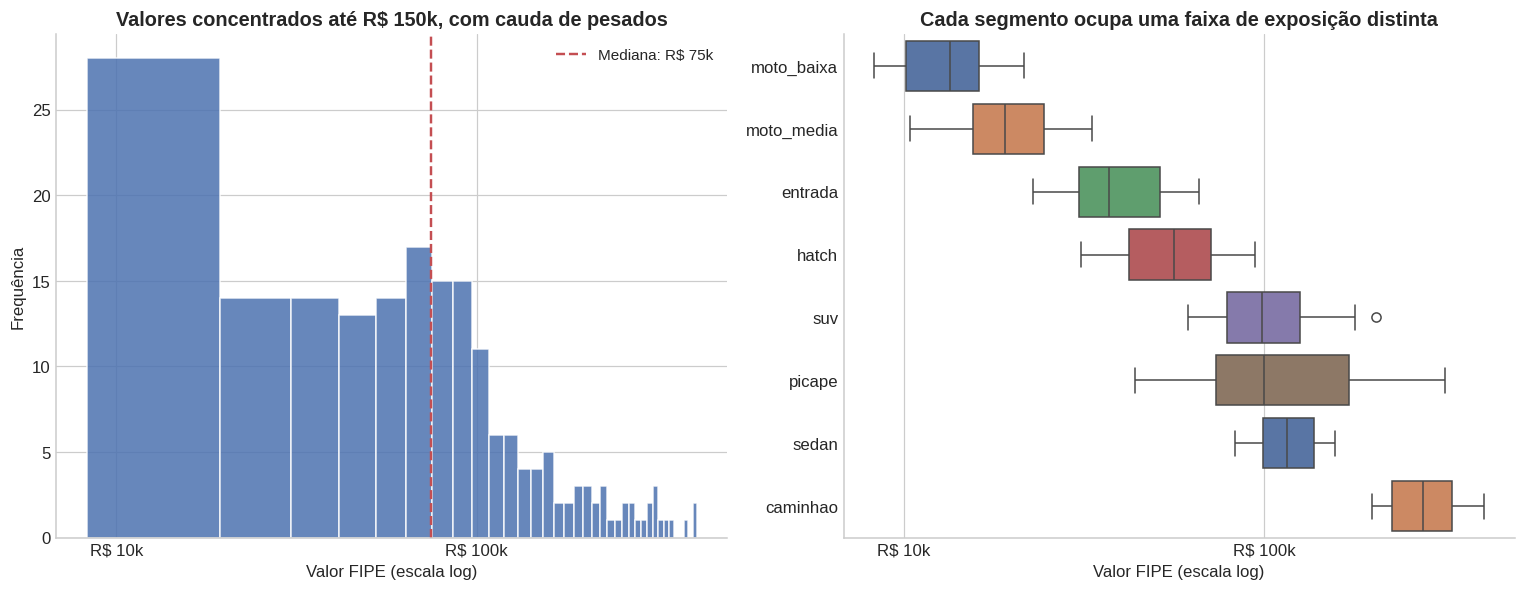

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Distribuição de valores (escala log: preços de veículos têm cauda longa)
ax = axes[0]
ax.hist(df['valor_num'], bins=36, color=PAL[0], edgecolor='white', alpha=0.85)
ax.axvline(df['valor_num'].median(), color=PAL[3], ls='--', lw=1.6,
           label=f"Mediana: {fmt_brl(df['valor_num'].median())}")
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title('Valores concentrados até R$ 150k, com cauda de pesados')
ax.set_xlabel('Valor FIPE (escala log)'); ax.set_ylabel('Frequência'); ax.legend()

# Dispersão de valor por segmento (ordenado pela mediana)
ax = axes[1]
ordem = df.groupby('segmento')['valor_num'].median().sort_values().index
sns.boxplot(data=df, y='segmento', x='valor_num', order=ordem, ax=ax, palette=PAL, orient='h')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title('Cada segmento ocupa uma faixa de exposição distinta')
ax.set_xlabel('Valor FIPE (escala log)'); ax.set_ylabel('')

for a in axes:
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Leitura de negócio:** a carteira não é homogênea — motos custam ~R$ 20k, caminhões ~R$ 400k. Um modelo
de mensalidade única ignora uma variação de **20x na exposição financeira**. Já justifica segmentar.

## 4 · Curvas de Depreciação

A depreciação importa para precificação porque define o **descasamento entre valor protegido e valor de mercado** ao
longo do contrato: quem deprecia rápido fica superprotegido (e a associação superexposta em perda total).

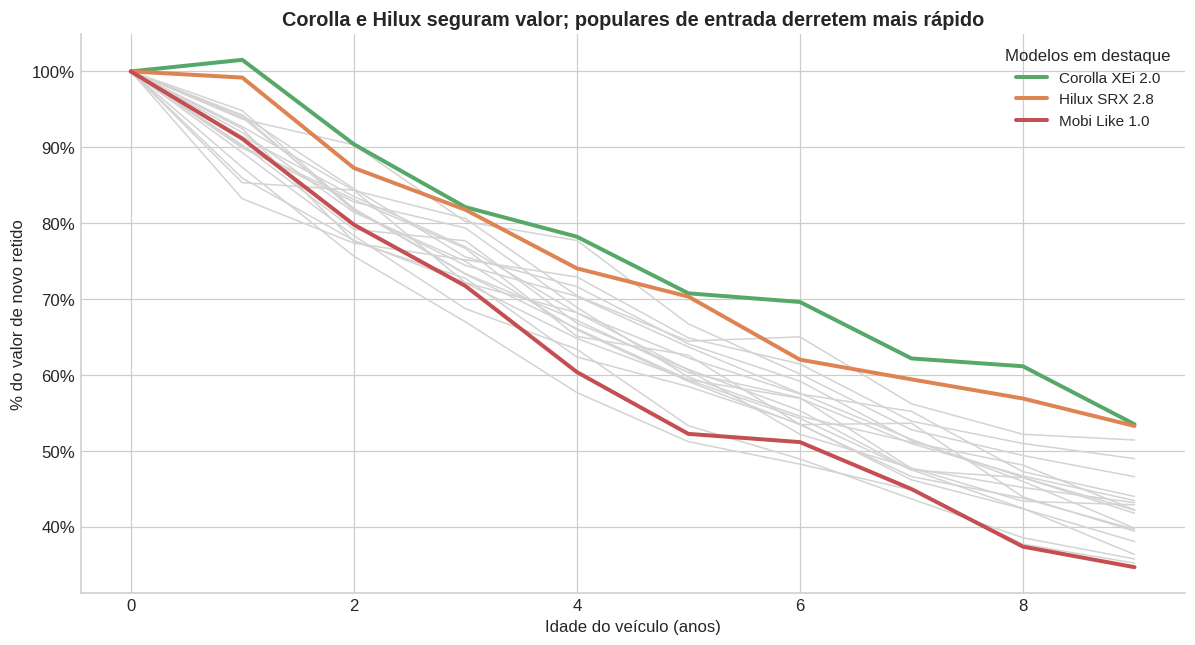

,marca,modelo,dep_anual_pct
1,Fiat,Mobi Like 1.0,11.100750
10,Jeep,Compass Longitude,10.951480
4,GM,Onix LT 1.0,10.796516
9,Hyundai,HB20 Comfort 1.0,10.633553
0,Fiat,Argo Drive 1.3,10.175992
19,Yamaha,Fazer FZ25,9.824742
16,VW,Polo Track 1.0,9.763331
15,VW,Nivus Highline,9.725186


In [6]:
# Curva de valor relativo (valor do ano / valor do 0 km do mesmo modelo)
ref = df[df.anomodelo == df.anomodelo.max()][['modelo', 'valor_num']].rename(columns={'valor_num': 'valor_novo'})
dfc = df.merge(ref, on='modelo')
dfc['idade'] = df.anomodelo.max() - dfc.anomodelo
dfc['valor_relativo'] = dfc.valor_num / dfc.valor_novo * 100

fig, ax = plt.subplots(figsize=(11, 6))
destaque = {'Corolla XEi 2.0': PAL[2], 'Mobi Like 1.0': PAL[3], 'Hilux SRX 2.8': PAL[1]}
for (mod, g) in dfc.groupby('modelo'):
    g = g.sort_values('idade')
    if mod in destaque:
        ax.plot(g.idade, g.valor_relativo, color=destaque[mod], lw=2.6, label=mod, zorder=3)
    else:
        ax.plot(g.idade, g.valor_relativo, color='lightgray', lw=1, zorder=1)

ax.set_title('Corolla e Hilux seguram valor; populares de entrada derretem mais rápido')
ax.set_xlabel('Idade do veículo (anos)'); ax.set_ylabel('% do valor de novo retido')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Modelos em destaque'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Taxa anual composta por modelo
def taxa_dep(g):
    g = g.sort_values('anomodelo')
    anos = g.anomodelo.max() - g.anomodelo.min()
    if anos <= 0 or g.valor_num.iloc[-1] <= 0: return np.nan
    return (1 - (g.valor_num.iloc[0] / g.valor_num.iloc[-1]) ** (1 / anos)) * 100

dep = df.groupby(['marca', 'modelo']).apply(taxa_dep, include_groups=False).rename('dep_anual_pct').reset_index()
df = df.merge(dep, on=['marca', 'modelo'], how='left')
dep.sort_values('dep_anual_pct', ascending=False).head(8)


## 5 · Score de Risco Composto

Quatro fatores normalizados (0–100), combinados com **pesos explícitos e auditáveis** — requisito num setor regulado,
onde a precificação precisa ser defensável perante diretoria e associados:

| Fator | Peso | Racional |
|---|---|---|
| Risco de furto/roubo (IVR) | 40% | Principal driver de sinistro de perda total |
| Exposição financeira | 30% | Tamanho da perda quando o sinistro ocorre |
| Depreciação anual | 20% | Descasamento valor protegido × mercado |
| Categoria | 10% | Frequência estrutural (moto > carro) |


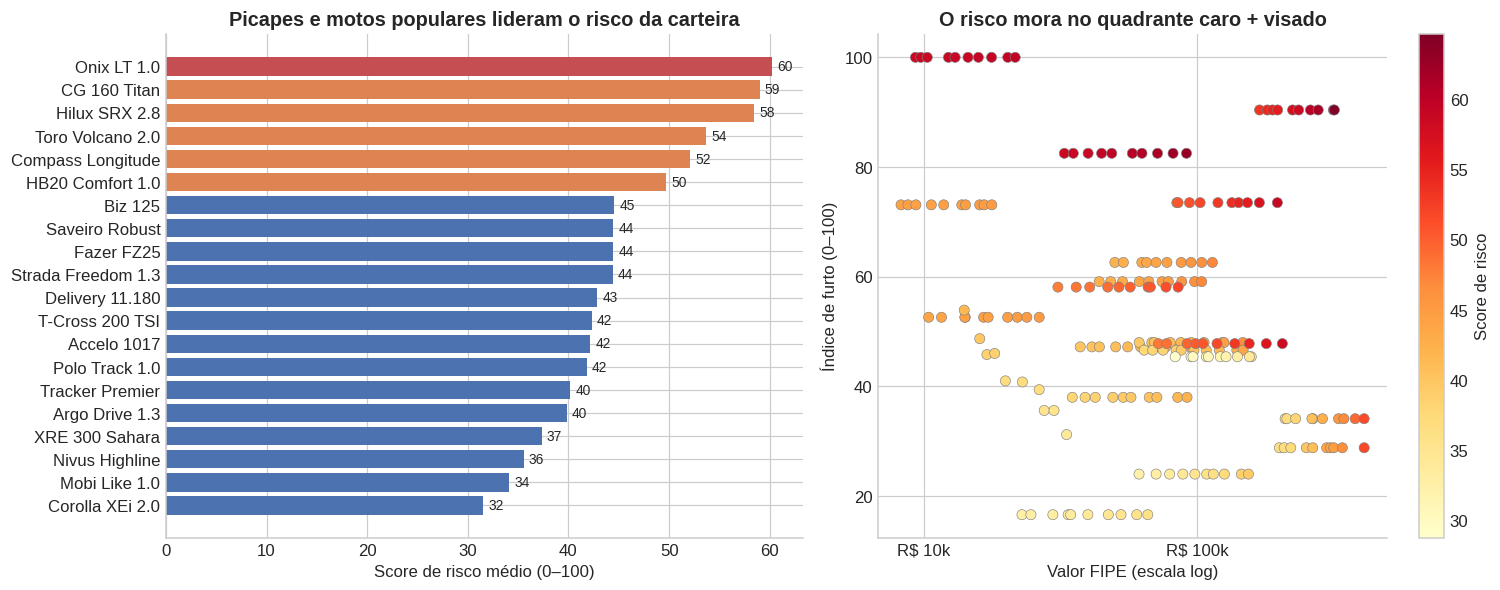

In [7]:
PESOS = {'furto': .40, 'exposicao': .30, 'depreciacao': .20, 'categoria': .10}
SCORE_CAT = {'motos': 85, 'caminhoes': 60, 'carros': 50}

def norm(s):
    lo, hi = s.min(), s.max()
    return pd.Series(50.0, index=s.index) if hi == lo else (s - lo) / (hi - lo) * 100

df['f_exposicao'] = norm(df.valor_num)
df['f_dep'] = norm(df.dep_anual_pct.fillna(df.dep_anual_pct.median()))
df['f_furto'] = df.risco_furto.clip(0, 100)
df['f_cat'] = df.tipo_veiculo.map(SCORE_CAT)

df['score_risco'] = (df.f_furto * PESOS['furto'] + df.f_exposicao * PESOS['exposicao']
                     + df.f_dep * PESOS['depreciacao'] + df.f_cat * PESOS['categoria']).round(1)
df['faixa_risco'] = pd.cut(df.score_risco, [0, 25, 50, 75, 101],
                           labels=['Baixo', 'Médio', 'Alto', 'Crítico'], right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Ranking de modelos por score médio
top = df.groupby('modelo').score_risco.mean().sort_values()
axes[0].barh(top.index, top.values,
             color=[PAL[3] if v >= 60 else PAL[1] if v >= 45 else PAL[0] for v in top.values])
for y, v in enumerate(top.values):
    axes[0].text(v + .5, y, f'{v:.0f}', va='center', fontsize=9)
axes[0].set_title('Picapes e motos populares lideram o risco da carteira')
axes[0].set_xlabel('Score de risco médio (0–100)')

# Mapa exposição × furto, colorido pelo score
sc = axes[1].scatter(df.valor_num, df.f_furto, c=df.score_risco, cmap='YlOrRd',
                     s=44, edgecolor='gray', lw=.4)
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
plt.colorbar(sc, ax=axes[1], label='Score de risco')
axes[1].set_title('O risco mora no quadrante caro + visado')
axes[1].set_xlabel('Valor FIPE (escala log)'); axes[1].set_ylabel('Índice de furto (0–100)')

for a in axes:
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 6 · ML — Parte 1: Segmentação de Perfis (K-Means)

O score ordena veículos numa régua única. A clusterização responde outra pergunta: **quantos perfis *naturais* de risco
existem na carteira?** Isso vira tabela de preços com N faixas — mais simples de comunicar ao associado do que um score contínuo.

A escolha de k usa dois critérios: cotovelo (inércia) e **coeficiente de silhueta** (separação real entre clusters).
A busca é limitada a **k ≤ 6** por uma restrição de negócio: tabela de preços com mais de 6 faixas é difícil de
comunicar e operar — interpretabilidade vale mais que um décimo de silhueta.

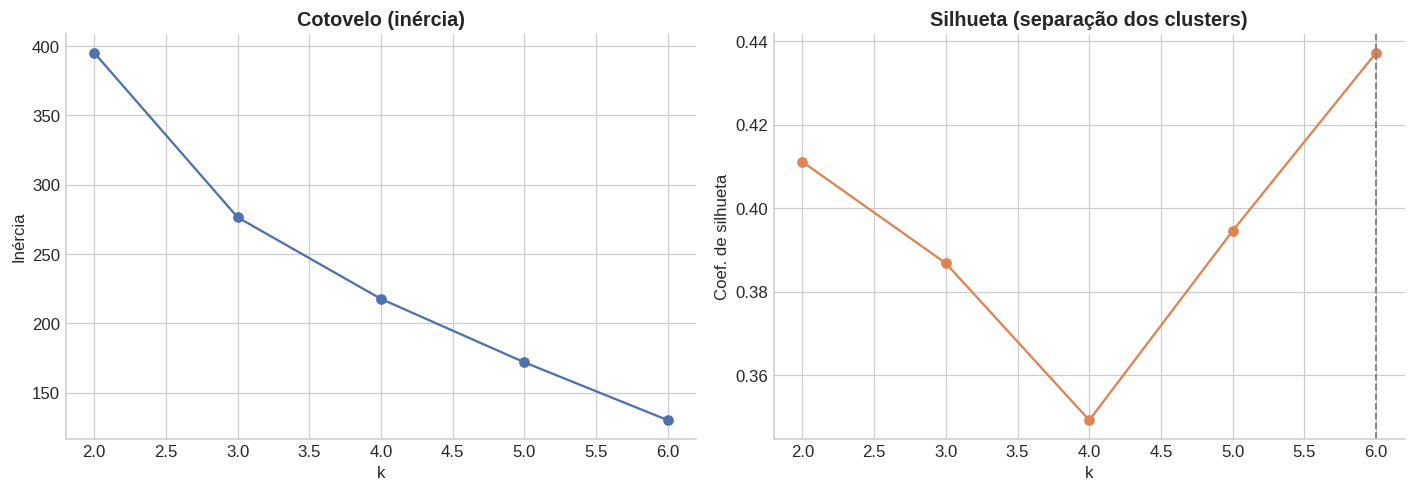

k escolhido pela silhueta: 6


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURES_SEG = ['valor_num', 'dep_anual_pct', 'risco_furto']
X = df[FEATURES_SEG].copy()
X['valor_num'] = np.log10(X['valor_num'])          # log: reduz dominância da cauda de pesados
X = X.fillna(X.median())
Xs = StandardScaler().fit_transform(X)

ks = range(2, 7)   # max 6: tabela de preços com mais faixas é impraticável de comunicar
inercia, silhueta = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xs)
    inercia.append(km.inertia_)
    silhueta.append(silhouette_score(Xs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(list(ks), inercia, 'o-', color=PAL[0]); axes[0].set_title('Cotovelo (inércia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inércia')
axes[1].plot(list(ks), silhueta, 'o-', color=PAL[1]); axes[1].set_title('Silhueta (separação dos clusters)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Coef. de silhueta')
k_otimo = list(ks)[int(np.argmax(silhueta))]
axes[1].axvline(k_otimo, ls='--', color='gray', lw=1.2)
for a in axes: a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()
print(f'k escolhido pela silhueta: {k_otimo}')


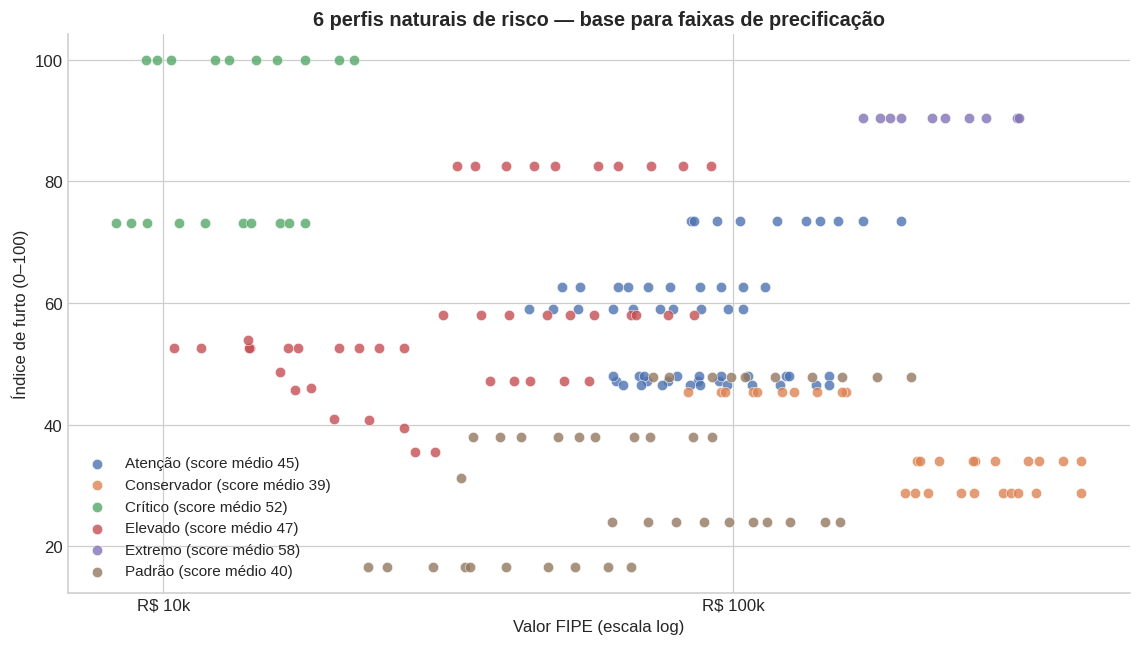

,n,valor_medio,dep_media,furto_medio,score_medio,exemplos
Conservador,30,230995.3,7.2,36.1,38.8,"Corolla XEi 2.0, Accelo 1017"
Padrão,41,81007.3,10.5,31.6,40.2,"Mobi Like 1.0, Argo Drive 1.3"
Atenção,55,93101.5,9.1,57.0,44.8,"Strada Freedom 1.3, Toro Volcano 2.0"
Elevado,44,39174.0,10.1,58.1,47.4,"Onix LT 1.0, HB20 Comfort 1.0"
Crítico,20,13608.8,8.5,86.6,51.8,"CG 160 Titan, Biz 125"
Extremo,10,236178.0,6.8,90.4,58.5,Hilux SRX 2.8


In [9]:
km = KMeans(n_clusters=k_otimo, n_init=10, random_state=SEED).fit(Xs)
df['cluster'] = km.labels_

perfil = df.groupby('cluster').agg(
    n=('modelo', 'size'),
    valor_medio=('valor_num', 'mean'),
    dep_media=('dep_anual_pct', 'mean'),
    furto_medio=('risco_furto', 'mean'),
    score_medio=('score_risco', 'mean'),
    exemplos=('modelo', lambda s: ', '.join(s.value_counts().head(2).index)),
).round(1).sort_values('score_medio')

# Nomeia os perfis em linguagem de negócio, do menor para o maior risco
base = ['Conservador', 'Padrão', 'Atenção', 'Elevado', 'Crítico', 'Extremo']
nomes = base[:k_otimo] if k_otimo <= len(base) else [f'Faixa {i+1}' for i in range(k_otimo)]
assert len(nomes) == len(perfil.index), 'nomeação deve cobrir todos os clusters'
mapa_nome = dict(zip(perfil.index, nomes))
df['perfil'] = df.cluster.map(mapa_nome)
perfil.index = [mapa_nome[i] for i in perfil.index]

fig, ax = plt.subplots(figsize=(10.5, 6))
for nome, g in df.groupby('perfil'):
    ax.scatter(g.valor_num, g.risco_furto, label=f'{nome} (score médio {g.score_risco.mean():.0f})',
               s=46, alpha=.8, edgecolor='white', lw=.4)
ax.set_xscale('log'); ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title(f'{k_otimo} perfis naturais de risco — base para faixas de precificação')
ax.set_xlabel('Valor FIPE (escala log)'); ax.set_ylabel('Índice de furto (0–100)')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

perfil


### 6.1 · Os perfis são estatisticamente distintos?

Clusters sempre "encontram" grupos — mesmo em ruído. Antes de virar tabela de preços, dois testes:
**Kruskal-Wallis** (não-paramétrico; o score difere entre perfis?) e **IC bootstrap de 95%** do score médio por perfil
(as faixas se sobrepõem?).

Kruskal-Wallis: H = 68.1, p-valor = 2.53e-13  -> perfis distintos


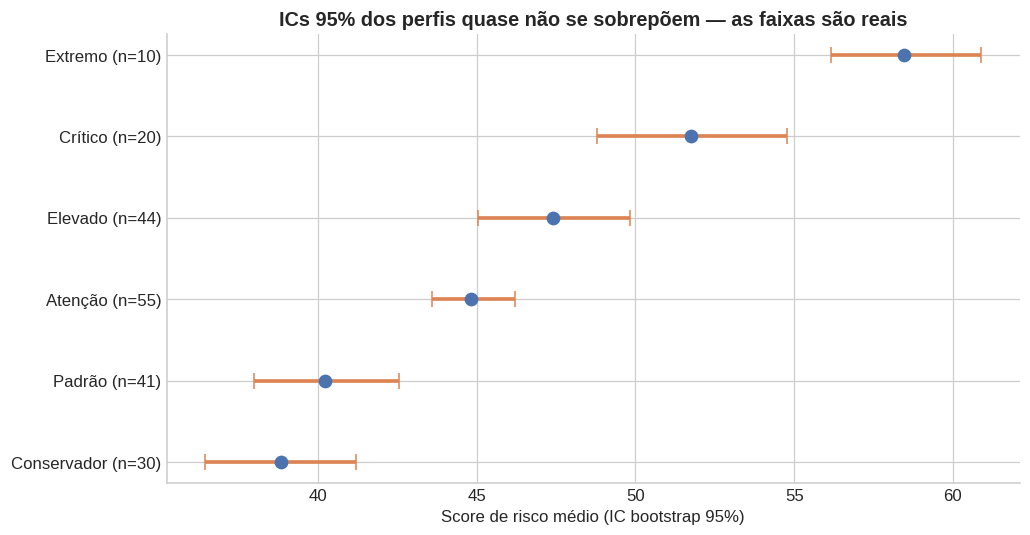

In [10]:
from scipy import stats

grupos = [g.score_risco.values for _, g in df.groupby('perfil')]
H, p = stats.kruskal(*grupos)
print(f'Kruskal-Wallis: H = {H:.1f}, p-valor = {p:.2e}' + ('  -> perfis distintos' if p < .05 else '  -> NÃO distintos'))

def boot_ci(vals, n_boot=2000, seed=SEED):
    bs = np.random.default_rng(seed).choice(vals, (n_boot, len(vals)), replace=True).mean(axis=1)
    return np.percentile(bs, [2.5, 97.5])

resumo = df.groupby('perfil').score_risco.agg(['mean','count']).sort_values('mean')
cis = np.array([boot_ci(df.loc[df.perfil == p_, 'score_risco'].values) for p_ in resumo.index])

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(resumo))
ax.errorbar(resumo['mean'], y, xerr=[resumo['mean'] - cis[:,0], cis[:,1] - resumo['mean']],
            fmt='o', color=PAL[0], ecolor=PAL[1], elinewidth=2.4, capsize=5, ms=8)
ax.set_yticks(y, [f'{p_} (n={int(n)})' for p_, n in zip(resumo.index, resumo['count'])])
ax.set_title('ICs 95% dos perfis quase não se sobrepõem — as faixas são reais')
ax.set_xlabel('Score de risco médio (IC bootstrap 95%)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 7 · ML — Parte 2: Previsão de Valor (Random Forest)

Modelo supervisionado para estimar o **valor FIPE a partir das características do veículo**. Utilidade prática:
estimar valor de proteção quando o veículo ainda não está na tabela de referência do mês, e detectar **outliers de
precificação** (veículos cujo valor real foge muito do previsto — candidatos a revisão de cadastro ou fraude).

Validação: K-Fold (5 dobras) com MAE e R², e comparação contra um baseline ingênuo (média por segmento).

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

df_ml = df.dropna(subset=['dep_anual_pct']).copy()
df_ml['idade'] = df_ml.anomodelo.max() - df_ml.anomodelo

FEAT_NUM = ['idade', 'dep_anual_pct', 'risco_furto']
FEAT_CAT = ['marca', 'segmento', 'tipo_veiculo']
ALVO = 'valor_num'

prep = ColumnTransformer([
    ('num', 'passthrough', FEAT_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEAT_CAT),
])

modelo = Pipeline([('prep', prep),
                   ('rf', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEED))])
baseline = Pipeline([('prep', prep), ('dummy', DummyRegressor(strategy='mean'))])

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'mae': 'neg_mean_absolute_error', 'r2': 'r2'}

res_m = cross_validate(modelo, df_ml[FEAT_NUM + FEAT_CAT], df_ml[ALVO], cv=cv, scoring=scoring)
res_b = cross_validate(baseline, df_ml[FEAT_NUM + FEAT_CAT], df_ml[ALVO], cv=cv, scoring=scoring)

print(f"Random Forest : MAE = {fmt_brl(-res_m['test_mae'].mean())} ± {fmt_brl(res_m['test_mae'].std())} | R² = {res_m['test_r2'].mean():.3f}")
print(f"Baseline média: MAE = {fmt_brl(-res_b['test_mae'].mean())} | R² = {res_b['test_r2'].mean():.3f}")


Random Forest : MAE = R$ 10k ± R$ 3k | R² = 0.964
Baseline média: MAE = R$ 65k | R² = -0.050


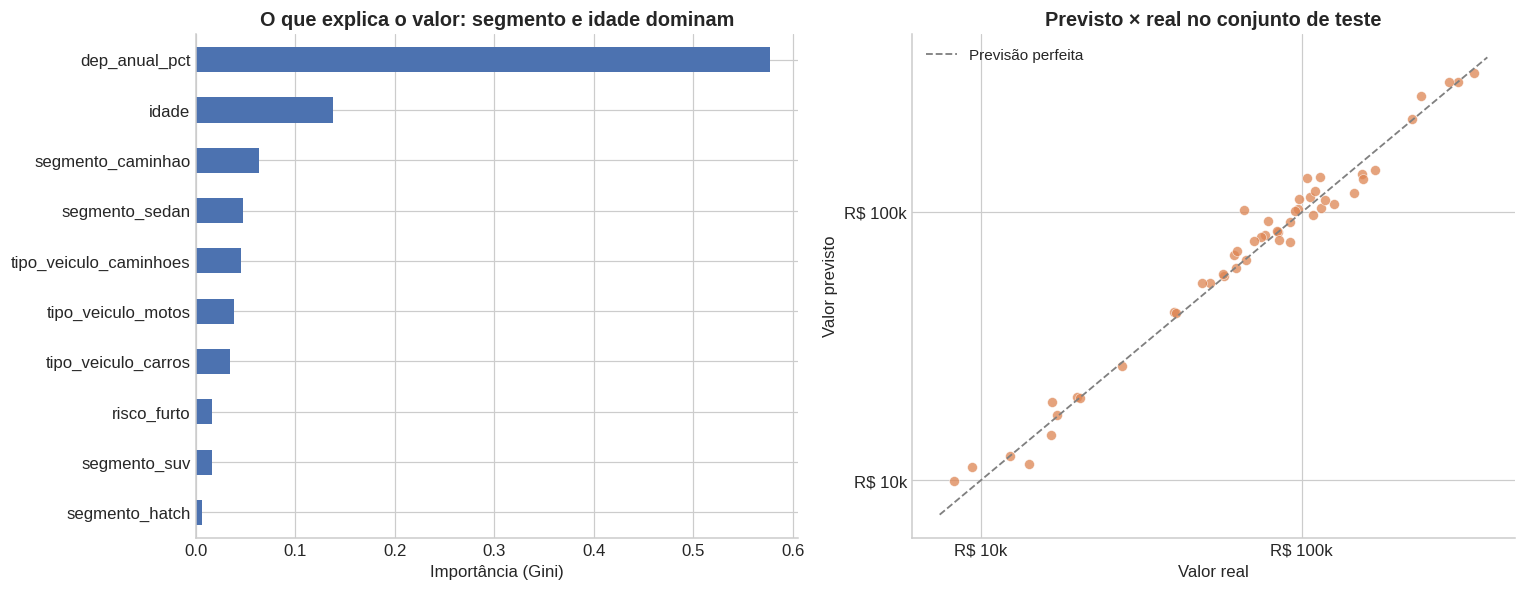

,marca,segmento,idade,real,previsto,desvio_pct
9,Fiat,entrada,0,66000.0,102195.022303,-35.4
68,VW,suv,1,145030.0,117953.943594,23.0
170,Honda,moto_media,9,14077.0,11502.653910,22.4
79,VW,picape,0,103869.0,133686.842312,-22.3
132,Jeep,suv,7,91891.0,77476.040970,18.6
38,Fiat,picape,1,168817.0,144237.374515,17.0


In [12]:
# Treino final + diagnóstico: importância de variáveis e previsto × real
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(df_ml[FEAT_NUM + FEAT_CAT], df_ml[ALVO],
                                          test_size=.25, random_state=SEED)
modelo.fit(X_tr, y_tr)
pred = modelo.predict(X_te)

# nomes das features pós one-hot
ohe = modelo.named_steps['prep'].named_transformers_['cat']
nomes_feat = FEAT_NUM + list(ohe.get_feature_names_out(FEAT_CAT))
imp = pd.Series(modelo.named_steps['rf'].feature_importances_, index=nomes_feat).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

imp.tail(10).plot.barh(ax=axes[0], color=PAL[0])
axes[0].set_title('O que explica o valor: segmento e idade dominam')
axes[0].set_xlabel('Importância (Gini)')

axes[1].scatter(y_te, pred, s=42, alpha=.75, color=PAL[1], edgecolor='white', lw=.4)
lim = [min(y_te.min(), pred.min()) * .9, max(y_te.max(), pred.max()) * 1.1]
axes[1].plot(lim, lim, '--', color='gray', lw=1.2, label='Previsão perfeita')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[1].set_title('Previsto × real no conjunto de teste')
axes[1].set_xlabel('Valor real'); axes[1].set_ylabel('Valor previsto'); axes[1].legend()

for a in axes: a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Outliers de precificação: maiores desvios percentuais
diag = X_te.copy()
diag['real'], diag['previsto'] = y_te.values, pred
diag['desvio_pct'] = ((diag.real - diag.previsto) / diag.previsto * 100).round(1)
diag.reindex(diag.desvio_pct.abs().sort_values(ascending=False).index)[
    ['marca', 'segmento', 'idade', 'real', 'previsto', 'desvio_pct']].head(6)


### 7.1 · Tuning de hiperparâmetros, importância por permutação e resíduos

Três upgrades de rigor: (1) **RandomizedSearchCV** em vez de hiperparâmetros chutados; (2) **importância por
permutação** no teste — a importância Gini é viesada para variáveis de alta cardinalidade e medida no treino;
(3) **análise de resíduos** — não basta saber quanto o modelo erra, importa saber *onde*.

Melhores params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
MAE teste — tunado: R$ 7k  |  default: R$ 9k


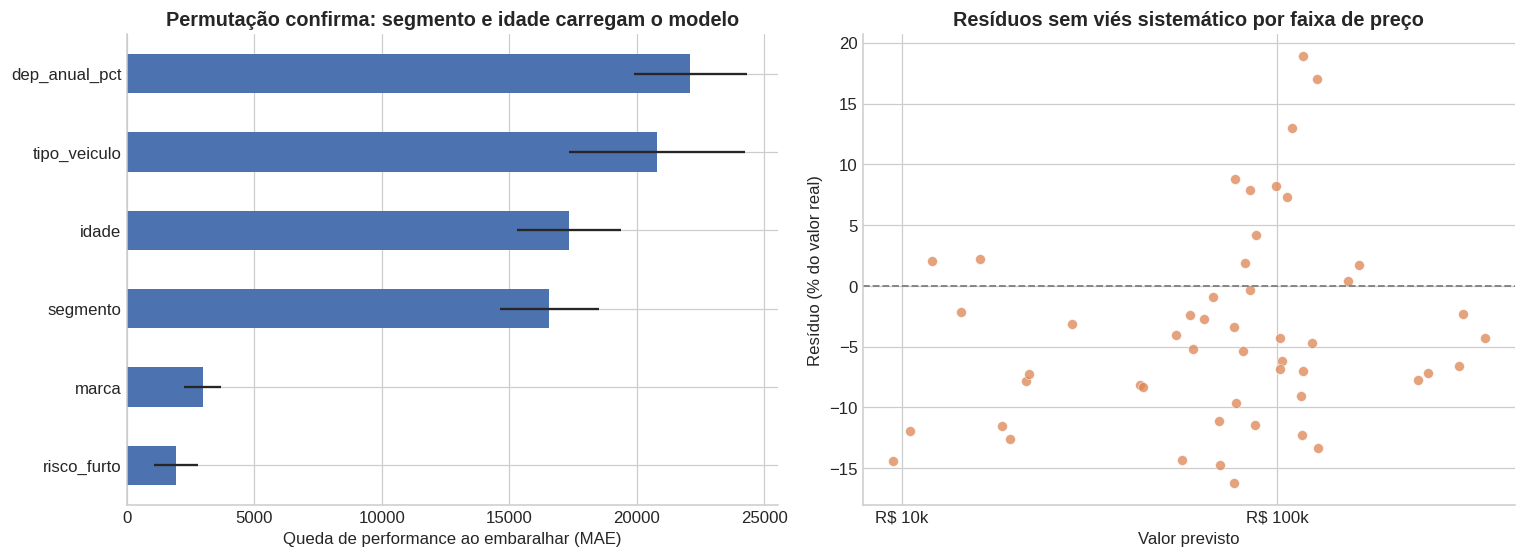

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance

espaco = {
    'rf__n_estimators': [200, 300, 500],
    'rf__max_depth': [None, 8, 12, 16],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 0.5, None],
}
busca = RandomizedSearchCV(modelo, espaco, n_iter=20, cv=cv,
                           scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=-1)
busca.fit(X_tr, y_tr)
melhor = busca.best_estimator_
pred_t = melhor.predict(X_te)
mae_t = np.abs(y_te - pred_t).mean()
print(f'Melhores params: { {k.replace("rf__",""): v for k, v in busca.best_params_.items()} }')
print(f'MAE teste — tunado: {fmt_brl(mae_t)}  |  default: {fmt_brl(np.abs(y_te - pred).mean())}')

perm = permutation_importance(melhor, X_te, y_te, n_repeats=20, random_state=SEED,
                              scoring='neg_mean_absolute_error')
imp_perm = pd.Series(perm.importances_mean, index=X_te.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
imp_perm.plot.barh(ax=axes[0], color=PAL[0],
                   xerr=pd.Series(perm.importances_std, index=X_te.columns)[imp_perm.index])
axes[0].set_title('Permutação confirma: segmento e idade carregam o modelo')
axes[0].set_xlabel('Queda de performance ao embaralhar (MAE)')

residuos = (y_te - pred_t) / y_te * 100
axes[1].scatter(pred_t, residuos, s=42, alpha=.75, color=PAL[1], edgecolor='white', lw=.4)
axes[1].axhline(0, color='gray', ls='--', lw=1.2)
axes[1].set_xscale('log'); axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[1].set_title('Resíduos sem viés sistemático por faixa de preço')
axes[1].set_xlabel('Valor previsto'); axes[1].set_ylabel('Resíduo (% do valor real)')
for a in axes: a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 8 · Detecção de Anomalias (Isolation Forest)

Aplicação direta ao negócio: **triagem de cadastro e antifraude**. Combinações atípicas de valor × depreciação × furto
indicam erro de tabela ou tentativa de superavaliação na adesão. O Isolation Forest isola esses pontos sem precisar de
rótulos de fraude.

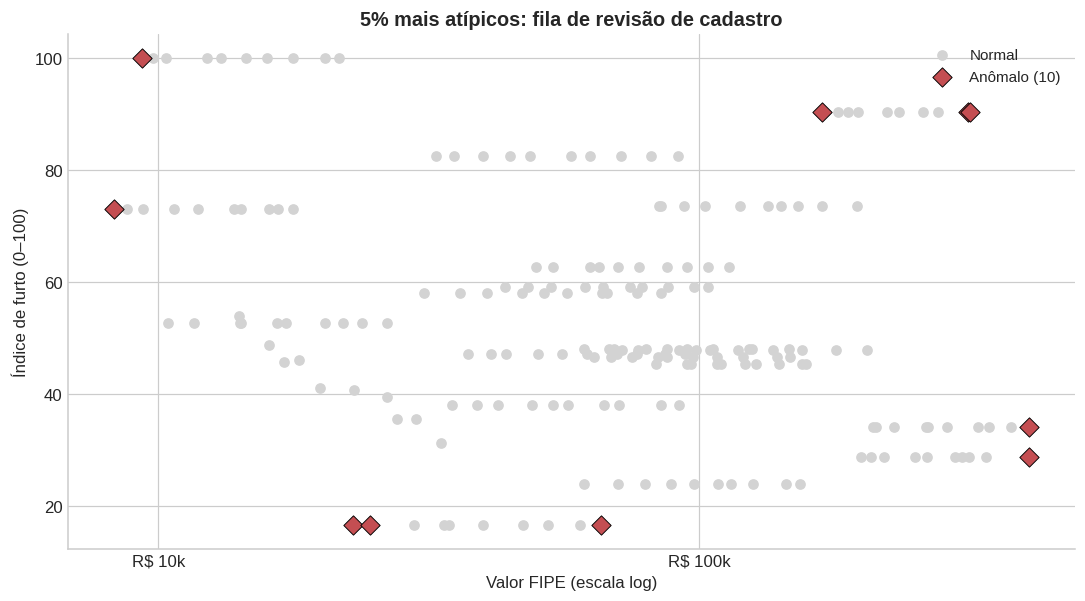

,marca,modelo,anomodelo,valor_num,dep_anual_pct,risco_furto
0,Fiat,Mobi Like 1.0,2017,22889.0,11.100750,16.6
189,M.Benz,Accelo 1017,2026,407902.0,7.623982,28.8
119,Toyota,Hilux SRX 2.8,2026,317330.0,6.755982,90.4
140,Honda,CG 160 Titan,2017,9335.0,8.909012,100.0
199,VW,Delivery 11.180,2026,407661.0,7.120851,34.1


In [14]:
from sklearn.ensemble import IsolationForest

X_anom = df[['valor_num','dep_anual_pct','risco_furto']].copy()
X_anom['valor_num'] = np.log10(X_anom['valor_num'])
X_anom = X_anom.fillna(X_anom.median())

iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=SEED).fit(X_anom)
df['anomalia'] = iso.predict(X_anom) == -1
df['score_anomalia'] = -iso.score_samples(X_anom)

fig, ax = plt.subplots(figsize=(10, 5.6))
normal, anom = df[~df.anomalia], df[df.anomalia]
ax.scatter(normal.valor_num, normal.risco_furto, s=36, color='lightgray', label='Normal')
ax.scatter(anom.valor_num, anom.risco_furto, s=80, color=PAL[3], edgecolor='black',
           lw=.6, marker='D', label=f'Anômalo ({len(anom)})')
ax.set_xscale('log'); ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title('5% mais atípicos: fila de revisão de cadastro')
ax.set_xlabel('Valor FIPE (escala log)'); ax.set_ylabel('Índice de furto (0–100)'); ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

anom.nlargest(5, 'score_anomalia')[['marca','modelo','anomodelo','valor_num','dep_anual_pct','risco_furto']]


## 9 · Robustez do Score: Monte Carlo nos Pesos

A crítica óbvia ao score composto: *"os pesos são arbitrários"*. Resposta quantitativa: perturbar os pesos
(Dirichlet centrada nos pesos-base) **5.000 vezes** e medir se o *ranking* de risco muda. Se a ordenação é estável
sob perturbação, a decisão de negócio não depende da escolha exata dos pesos.

**Resultado em duas partes:** o *ranking* é robusto (Spearman ~0,91), mas ~17% dos veículos trocam de faixa —
o problema não são os pesos, são os **cortes fixos em 25/50/75**, que jogam veículos de fronteira para lá e
para cá. Recomendação: usar as faixas do K-Means (fronteiras naturais dos dados) como tabela de preços, e
reservar o score contínuo para análises internas.

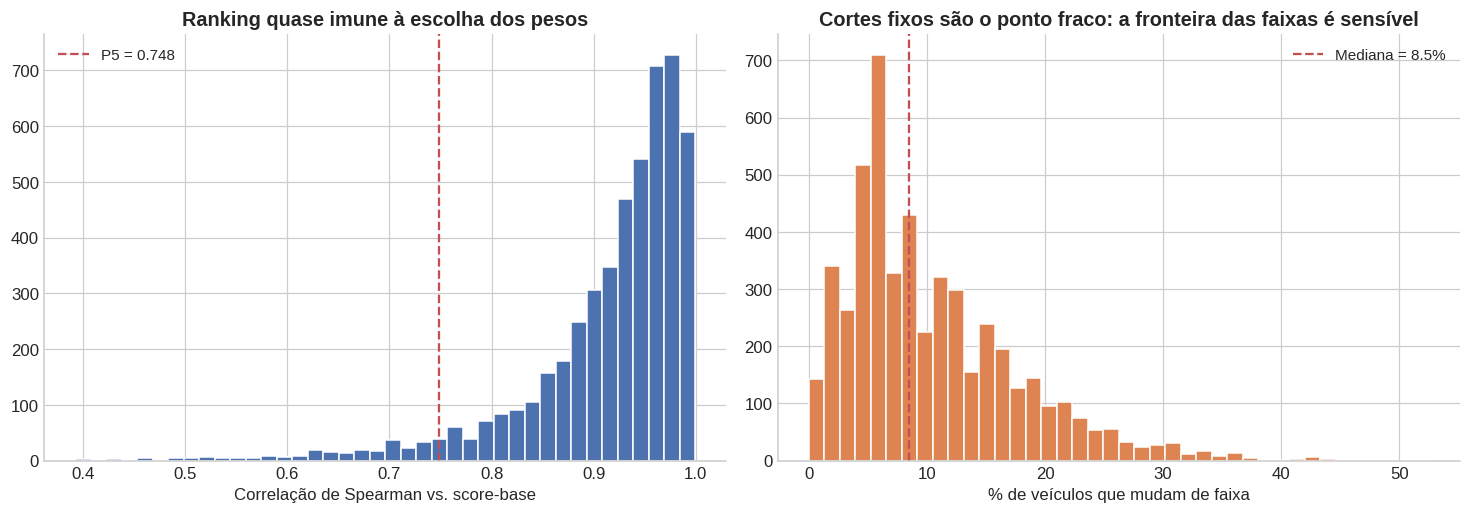

Spearman mediano: 0.941 | mudança de faixa mediana: 8.5%


In [15]:
from scipy.stats import spearmanr

F = df[['f_furto','f_exposicao','f_dep','f_cat']].values
w_base = np.array([PESOS['furto'], PESOS['exposicao'], PESOS['depreciacao'], PESOS['categoria']])
score_base = F @ w_base
faixa_base = pd.cut(score_base, [0,25,50,75,101], labels=False, right=False)

N = 5000
W = rng.dirichlet(w_base * 30, size=N)          # concentração 30: perturbação realista (~±30% relativos)
rhos, mudancas = np.empty(N), np.empty(N)
for i in range(N):
    s = F @ W[i]
    rhos[i] = spearmanr(score_base, s).statistic
    mudancas[i] = (pd.cut(s, [0,25,50,75,101], labels=False, right=False) != faixa_base).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].hist(rhos, bins=40, color=PAL[0], edgecolor='white')
axes[0].axvline(np.percentile(rhos, 5), color=PAL[3], ls='--',
                label=f'P5 = {np.percentile(rhos,5):.3f}')
axes[0].set_title('Ranking quase imune à escolha dos pesos')
axes[0].set_xlabel('Correlação de Spearman vs. score-base'); axes[0].legend()

axes[1].hist(mudancas, bins=40, color=PAL[1], edgecolor='white')
axes[1].axvline(np.median(mudancas), color=PAL[3], ls='--',
                label=f'Mediana = {np.median(mudancas):.1f}%')
axes[1].set_title('Cortes fixos são o ponto fraco: a fronteira das faixas é sensível')
axes[1].set_xlabel('% de veículos que mudam de faixa'); axes[1].legend()
for a in axes: a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(f'Spearman mediano: {np.median(rhos):.3f} | mudança de faixa mediana: {np.median(mudancas):.1f}%')


## 10 · Da Análise ao Preço: Simulação de Mensalidade

Fechando o ciclo: o score vira número de negócio. Modelo de **prêmio puro** simplificado e *ilustrativo*
(calibração real exigiria a sinistralidade da carteira):

`perda esperada anual = frequência proxy (IVR) × valor exposto` → `mensalidade = (perda esperada × (1 + carregamento)) / 12`

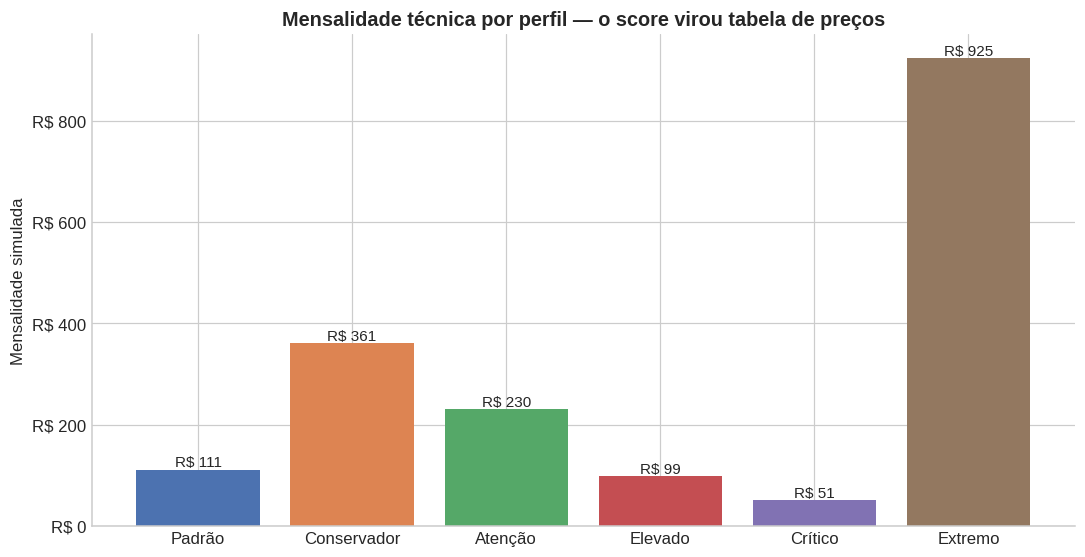

,valor_medio,furto_medio,n,freq_proxy,perda_esperada_anual,mensalidade,pct_valor_mes
perfil,,,,,,,
Padrão,81007.29,31.59,41,0.01,1023.62,110.89,0.14
Conservador,230995.33,36.10,30,0.01,3335.57,361.35,0.16
Atenção,93101.45,56.98,55,0.02,2122.04,229.89,0.25
Elevado,39174.02,58.06,44,0.02,909.83,98.57,0.25
Crítico,13608.80,86.55,20,0.03,471.14,51.04,0.38
Extremo,236178.00,90.40,10,0.04,8540.20,925.19,0.39


In [16]:
FREQ_BASE_ANUAL = 0.040    # proxy: 4% a.a. de frequência de perda total no pior risco
CARREGAMENTO = 0.30        # despesas + margem prudencial

sim = df.groupby('perfil').agg(valor_medio=('valor_num','mean'),
                               furto_medio=('f_furto','mean'),
                               n=('modelo','size')).sort_values('furto_medio')
sim['freq_proxy'] = FREQ_BASE_ANUAL * sim.furto_medio / 100
sim['perda_esperada_anual'] = sim.freq_proxy * sim.valor_medio
sim['mensalidade'] = sim.perda_esperada_anual * (1 + CARREGAMENTO) / 12
sim['pct_valor_mes'] = sim.mensalidade / sim.valor_medio * 100

fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.bar(sim.index, sim.mensalidade, color=PAL[:len(sim)])
for b, v in zip(bars, sim.mensalidade):
    ax.text(b.get_x() + b.get_width()/2, v, fmt_brl(v), ha='center', va='bottom', fontsize=10)
ax.set_title('Mensalidade técnica por perfil — o score virou tabela de preços')
ax.set_ylabel('Mensalidade simulada')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

sim.round(2)


### 10.1 · Fator condutor: idade

O IVR da SUSEP também segmenta por **faixa etária do condutor** — o terceiro eixo clássico de tarifação
(veículo × região × condutor). Convertendo o índice em **multiplicadores relativos** (referência: faixa 36–45 = 1,00,
padrão atuarial), a mensalidade técnica vira uma **matriz veículo × condutor**.

*Caveat honesto: associações de proteção veicular nem sempre tarifam por idade (decisão comercial/estatutária);
aqui o fator é apresentado como instrumento — usá-lo é decisão de negócio.*

Fonte: ../data/ivr_faixa_etaria_amostra.csv | referência 36-45 = 1.00


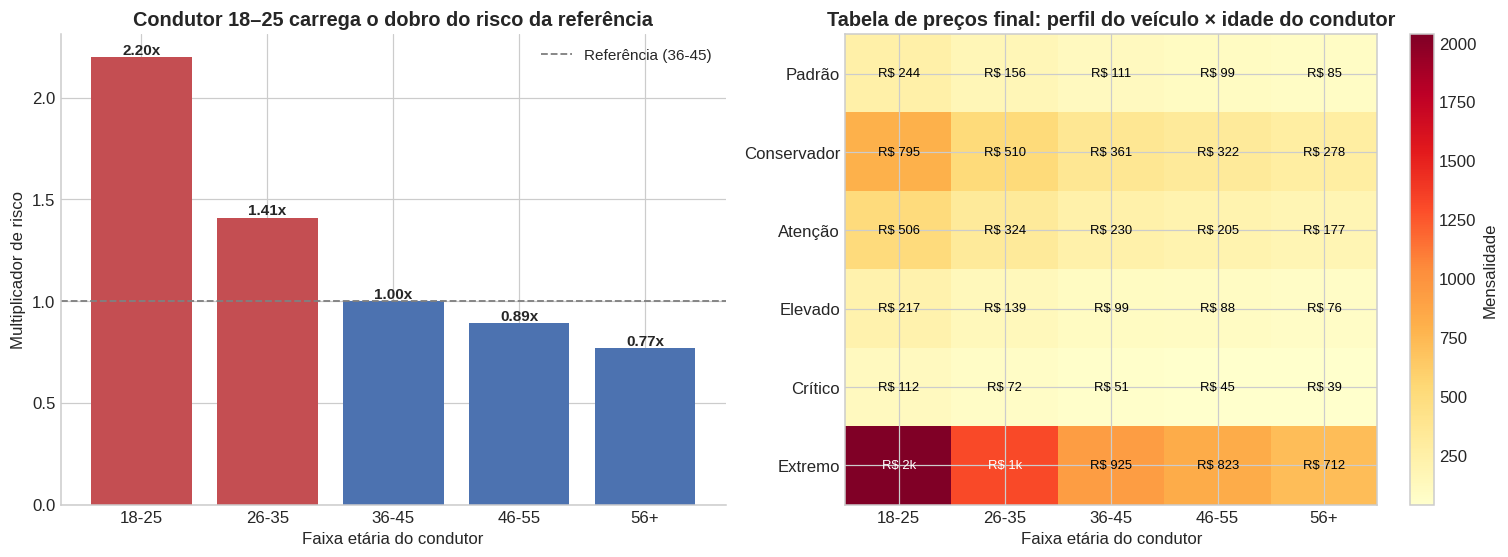

In [17]:
ARQ_IDADE = next((p for p in [Path('data/ivr_faixa_etaria.csv'), Path('../data/ivr_faixa_etaria.csv'),
                               Path('data/ivr_faixa_etaria_amostra.csv'), Path('../data/ivr_faixa_etaria_amostra.csv')]
                  if p.exists()), None)
assert ARQ_IDADE is not None, 'CSV de faixa etária não encontrado em data/'

idade_df = pd.read_csv(ARQ_IDADE, sep=';')
REF = '36-45'
base_ref = idade_df.loc[idade_df.faixa_etaria == REF, 'indice'].iloc[0]
idade_df['multiplicador'] = (idade_df.indice / base_ref).round(2)
print(f'Fonte: {ARQ_IDADE} | referência {REF} = 1.00')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Multiplicadores por faixa
cores = [PAL[3] if m > 1.3 else PAL[1] if m > 1.0 else PAL[0] for m in idade_df.multiplicador]
bars = axes[0].bar(idade_df.faixa_etaria, idade_df.multiplicador, color=cores)
axes[0].axhline(1.0, color='gray', ls='--', lw=1.2, label=f'Referência ({REF})')
for b, m in zip(bars, idade_df.multiplicador):
    axes[0].text(b.get_x() + b.get_width()/2, m, f'{m:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Condutor 18–25 carrega o dobro do risco da referência')
axes[0].set_xlabel('Faixa etária do condutor'); axes[0].set_ylabel('Multiplicador de risco'); axes[0].legend()

# Matriz mensalidade: perfil de veículo x faixa etária
matriz = pd.DataFrame({fx: sim.mensalidade * m
                       for fx, m in zip(idade_df.faixa_etaria, idade_df.multiplicador)},
                      index=sim.index)
im = axes[1].imshow(matriz.values, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(matriz.columns)), matriz.columns)
axes[1].set_yticks(range(len(matriz.index)), matriz.index)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        v = matriz.values[i, j]
        axes[1].text(j, i, fmt_brl(v), ha='center', va='center', fontsize=8.5,
                     color='white' if v > matriz.values.max()*.6 else 'black')
axes[1].set_title('Tabela de preços final: perfil do veículo × idade do condutor')
axes[1].set_xlabel('Faixa etária do condutor')
plt.colorbar(im, ax=axes[1], label='Mensalidade')

axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 11 · Conclusões de Negócio

1. **Mensalidade única é insustentável**: a exposição financeira varia ~20x entre segmentos, e o índice de furto varia
   de forma independente do valor. Os dois eixos juntos definem o risco — e ignorá-los gera seleção adversa.
2. **O quadrante crítico é "caro + visado"**: picapes (Hilux, Strada, Saveiro) e motos populares (CG 160) concentram
   score alto por motivos diferentes — picape pela exposição, moto pela frequência de furto. A resposta de precificação
   deve ser diferente (franquia/rastreador obrigatório vs. mensalidade ajustada).
3. **Os perfis do K-Means viram tabela de preços**: faixas naturais encontradas nos dados, defensáveis tecnicamente e
   simples de comunicar.
4. **A robustez foi testada, não assumida**: Kruskal-Wallis + bootstrap confirmam que os perfis são
   estatisticamente distintos, e o Monte Carlo mostra que o ranking de risco sobrevive à perturbação dos pesos.
5. **A matriz final cruza os três eixos clássicos de tarifação** — veículo (score), região (IVR) e condutor
   (faixa etária) — chegando à estrutura de uma tabela de preços de mercado.
6. **Isolation Forest e o regressor formam a triagem antifraude**: desvios grandes entre valor real e previsto sinalizam erro
   de tabela ou tentativa de superavaliação na adesão.

### Limitações e próximos passos
- O **IVR mede frequência de roubo, não probabilidade ajustada por frota** — modelos populares aparecem mais em parte
  porque há mais deles rodando. Versão 2: normalizar pelo tamanho da frota (dados Senatran/Base dos Dados).
- Substituir o índice público pela **sinistralidade interna da carteira** elevaria o modelo de proxy para medida direta.
- Levar o gold para o **Power BI** (modelo estrela) e expor a tabela de faixas numa **calculadora what-if em Excel**.

---
*Dados: API FIPE (parallelum.com.br) e IVR/SUSEP. Quando executado offline, usa gerador sintético calibrado com
parâmetros realistas de mercado — a metodologia é idêntica nos dois modos.*